In [134]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import PredefinedSplit
from sklearn.utils import resample
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed = 1234

In [141]:
lr_random_search_params = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__class_weight': [None, 'balanced'],
    'clf__max_iter': [100, 500, 1000]
}

rfc_random_search_params = {
    'n_estimators': [100, 200, 300],    # 100
    'max_depth': [5, 10, 20, 50, 100],     # None  
    'min_samples_split': [2, 4, 6],        # 2 1 failed
    'min_samples_leaf': [1, 2, 4],      # 1
    'class_weight': [None, "balanced"]
}

xgbc_random_search_params = {
    'clf__n_estimators': [1000, 2000, 3000],
    'clf__max_depth': [2, 3, 5, 7],
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'clf__subsample': [0.6, 0.8, 1.0],
    'clf__colsample_bytree': [0.6, 0.8, 1.0],
}

In [128]:
def accuracy_visual(classifier, X_tr, X_te, y_tr, y_te):
    tr = classifier.predict(X_tr)
    te = classifier.predict(X_te)
    as_tr = accuracy_score(y_tr, tr)
    as_te = accuracy_score(y_te, te)

    fig, ax = plt.subplots()
    bars = ax.bar(['Train', 'Train Baseline', 'Test', 'Test Baseline'], 
                  [as_tr*100, max(y_tr.mean(), 1 - y_tr.mean())*100, 
                   as_te*100, max(y_te.mean(), 1 - y_te.mean())*100], color=['steelblue', 'teal'])
    ax.bar_label(bars, fmt='%.1f%%')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    plt.show()

    cm = confusion_matrix(y_te, te)
    ConfusionMatrixDisplay.from_predictions(y_te, te)


### ____________________________________

In [145]:
DATA_PATHS = ["processed_data/data_day_2025.parquet",
              "processed_data/data_day_2024.parquet"]
df = pd.DataFrame()
for path in DATA_PATHS:
    df = pd.concat([df, pd.read_parquet(path)], ignore_index=True)


In [146]:
X = df.drop(columns=["Ticker", "Date", "Outcome"])
y = df["Outcome"]

print(X)
print(y)

          VWAP       EMA9      EMA20   Open    Close     High      Low  \
0      10.1500  10.147792  10.140362  10.16  10.1500  10.1600  10.1500   
1       1.0378   0.907025   0.871011   0.88   1.1500   1.1500   0.8800   
2       1.1328   0.935620   0.888058   1.18   1.0500   1.2799   1.0300   
3       1.5640   1.190996   1.044674   1.33   1.7000   1.7500   1.3300   
4       2.0730   1.396797   1.156610   1.75   2.2200   2.3000   1.7400   
...        ...        ...        ...    ...      ...      ...      ...   
12269   6.5994   6.079198   5.843617   5.95   6.4900   7.2000   5.9500   
12270   7.9322   6.474687   6.076884   7.50   7.8800   8.4399   7.3500   
12271   8.1383   7.747171   7.513304   8.07   8.0600   8.9500   7.5200   
12272   4.7271   3.965281   4.136176   3.83   4.7499   5.4400   3.7200   
12273   2.8479   2.116979   2.167765   2.66   2.5400   3.3700   2.3501   

       NumTrades  RelVolume       Gap%  
0           16.0   5.759458   0.098522  
1         1462.0  23.849380  

In [147]:
X_tr_val, X_te, y_tr_val, y_te = train_test_split(X, y, test_size=0.2, random_state = seed)
X_tr, X_val, y_tr, y_val = train_test_split(X_tr_val, y_tr_val, test_size=0.25, random_state = seed)

# Train-Test-Validation = (60-20-20)
print(X_tr)

          VWAP       EMA9      EMA20    Open   Close     High     Low  \
262     1.5114   0.845537   0.674113   1.900   1.461   2.0000   1.280   
2339   10.3875  10.061105   9.967116  10.020  10.410  10.9413  10.020   
753     4.6270   3.134570   3.071429   4.552   4.900   5.6110   3.606   
1658   12.5115  10.179221   9.693882  10.860  12.840  13.4099  10.840   
5120   14.6283  15.298571  15.584058  15.150  14.850  15.2000  14.340   
...        ...        ...        ...     ...     ...      ...     ...   
9188   10.9883  11.425938  11.811380  11.390  10.930  11.4100  10.890   
4303    6.4944   4.711458  14.920276   5.010   6.240   7.9800   4.890   
777     3.3843   2.759423   2.610990   3.000   2.900   3.0000   2.660   
10226   7.8410   8.270069   8.501585   7.850   7.860   8.0700   7.760   
1297   17.5063  23.065148  25.542224  17.550  17.520  17.6852  17.300   

       NumTrades  RelVolume       Gap%  
262       4801.0  19.264591  80.952381  
2339        80.0   5.902815   0.498480  


In [148]:
X_tr_sample, y_tr_sample = resample(X_tr, y_tr, n_samples=10000, random_state = seed)
X_combined = np.vstack([X_tr_sample, X_val])
y_combined = np.concatenate([y_tr_sample, y_val])
split_index = np.concatenate([-np.ones(len(X_tr_sample)), np.zeros(len(X_val))])
ps = PredefinedSplit(split_index)

# Linear Regression

{'clf__max_iter': 100, 'clf__class_weight': 'balanced', 'clf__C': 1}


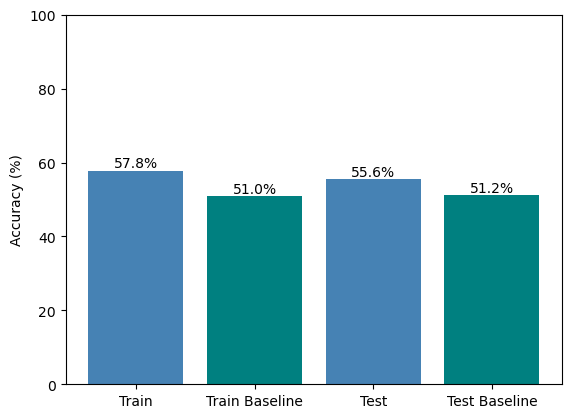

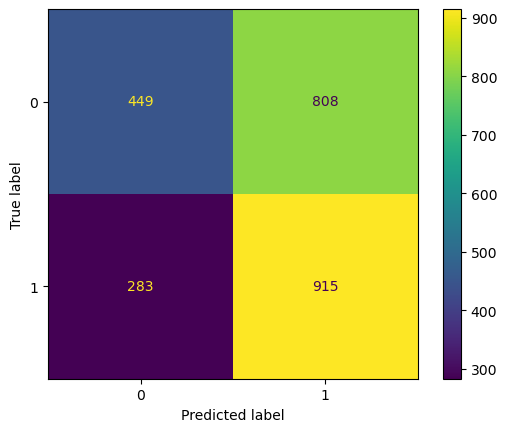

In [149]:
lr_random_search = RandomizedSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000))
    ]),
    lr_random_search_params,
    n_iter = 30,           # combos
    cv = ps,               # cross validation
    random_state=seed
)

lr_random_search.fit(X_combined, y_combined)
best_params = {k.replace("clf__", ""): v for k, v in lr_random_search.best_params_.items()}
print(lr_random_search.best_params_)

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=seed, **best_params))
])
lr.fit(X_tr, y_tr)

accuracy_visual(lr, X_tr, X_te, y_tr, y_te)

# Random Forests

{'n_estimators': 100, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_depth': 5, 'class_weight': None}


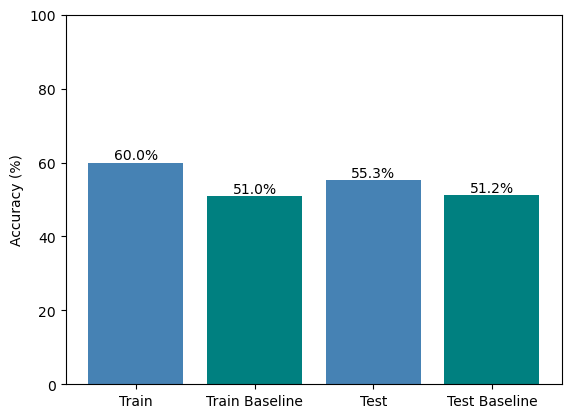

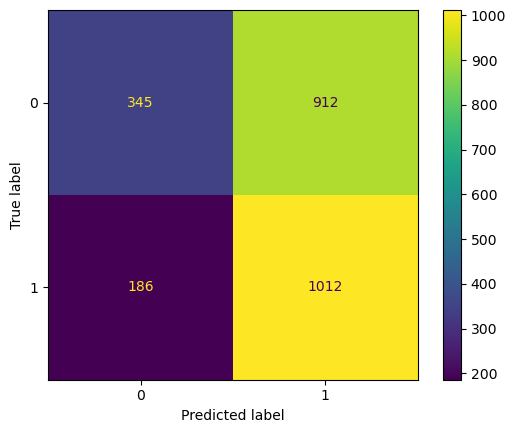

In [150]:
rfc_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=seed), 
    rfc_random_search_params,
    n_iter = 30,           # combos
    cv = ps,               # cross validation
    random_state=seed
)

rfc_random_search.fit(X_combined, y_combined)
print(rfc_random_search.best_params_)

rfc = RandomForestClassifier(random_state=seed, **rfc_random_search.best_params_)
rfc.fit(X_tr, y_tr)

accuracy_visual(rfc, X_tr, X_te, y_tr, y_te)

# XGB Classifier

{'clf__subsample': 1.0, 'clf__n_estimators': 2000, 'clf__max_depth': 5, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.8}


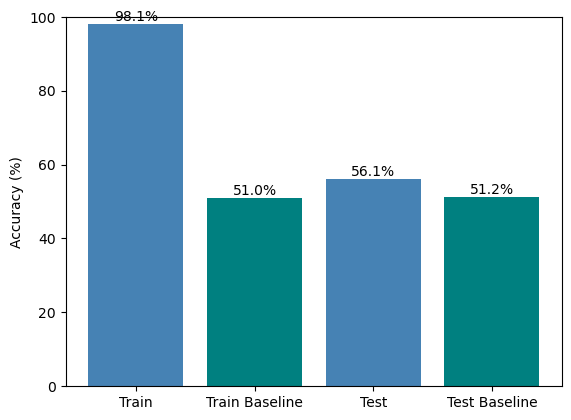

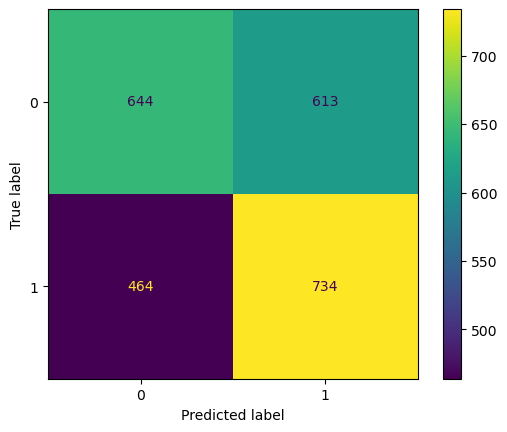

In [151]:
xgbc_random_search = RandomizedSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier())
    ]),
    xgbc_random_search_params,
    n_iter = 30,           # combos
    cv = ps,               # cross validation
    random_state=seed
)

xgbc_random_search.fit(X_combined, y_combined)
best_params = {k.replace("clf__", ""): v for k, v in xgbc_random_search.best_params_.items()}
print(xgbc_random_search.best_params_)

xgbc = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(random_state=seed, **best_params))
])
xgbc.fit(X_tr, y_tr)

accuracy_visual(xgbc, X_tr, X_te, y_tr, y_te)